In [85]:
image_set = "farfetch"
text_set = "nemotron"
embedding_mode = "clip"

In [86]:
step_n = 10

In [87]:
from transformers import CLIPProcessor, CLIPModel
processor = CLIPProcessor.from_pretrained("patrickjohncyh/fashion-clip")
model = CLIPModel.from_pretrained("patrickjohncyh/fashion-clip")

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

In [88]:
import os
import pickle

with open(f"{image_set}+{text_set}/{embedding_mode}/drift_sorted_indices/sorted_indices{step_n}.pkl", "rb") as f:
    sorted_indices = pickle.load(f)
with open(f"{image_set}+{text_set}/{embedding_mode}/drift_sorted_indices/results{step_n}.pkl", "rb") as f:
    results = pickle.load(f)

In [89]:
with open(f"../data_preparation/{text_set}/{embedding_mode}/train_persona_embeddings.pkl", "rb") as f:
    embeddings = pickle.load(f)

import torch.nn.functional as F

embeddings = embeddings.to("cpu").float()
embeddings = F.normalize(embeddings, p=2, dim=1)
results = F.normalize(results, p=2, dim=1)

results = results.to("cpu").float()
dot_products_list = embeddings @ results.T

0.23620667 -0.021413993


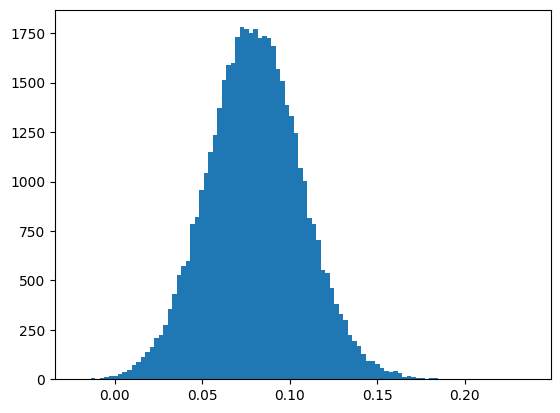

In [90]:
import matplotlib.pyplot as plt
import random


n = random.randint(0, len(dot_products_list) - 1)
scores = dot_products_list[n].cpu().numpy()

_ = plt.hist(scores, bins=100)
print(max(scores), min(scores))

In [91]:
import json
import pickle

with open(f"../data_preparation/{image_set}/images_train.pkl", "rb") as f:
    images = pickle.load(f)
with open(f"../data_preparation/{text_set}/train_personas.json", "r") as f:
    personas = json.load(f)
with open(f"../data_preparation/{text_set}/{embedding_mode}/train_persona_embeddings.pkl", "rb") as f:
    embeddings = pickle.load(f)

In [92]:
import torch
import random
import numpy as np

def sample_indices(scores, batch_size=5):
    indices = list(range(len(scores)))
    a = min(scores)
    b = max(scores)
    splits = [0, 0.7, 0.9, 0.95]
    bins = [a + (b - a) * split for split in splits]
    bin_ids = np.digitize(scores, bins, right=False)
    grouped = [[] for _ in range(batch_size - 1)]
    for idx, b in zip(indices, bin_ids):
        grouped[b - 1].append(idx)

    sampled_indices = []
    for i in range(batch_size - 1):
        if i < batch_size - 2:
            if len(grouped[i]) > 0:
                sampled_indices.extend(random.sample(grouped[i], 1))
            else:
                sampled_indices.extend(random.sample(indices, 1))
        else:
            if len(grouped[i]) > 1:
                sampled_indices.extend(random.sample(grouped[i], 2))
            else:
                sampled_indices.extend(random.sample(indices, 2))
    return sampled_indices

# %%
def sample_random_batch(embeddings, personas, dot_products_list, batch_size=5):
    persona_idx = random.randint(0, len(embeddings) - 1)
    persona_embedding = embeddings[persona_idx]
    persona_text = personas[persona_idx]

    scores = dot_products_list[persona_idx]
    print(len(scores))
    image_indices = sample_indices(scores, batch_size)

    return persona_embedding, persona_text, image_indices


In [93]:
import matplotlib.pyplot as plt

46910
Ilane, the organized worrier, ensures her workspace is pristine, but her desk drawer reveals a secret stash of stress-busting candy


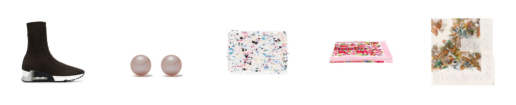

In [94]:
result = sample_random_batch(embeddings, personas, dot_products_list, batch_size=5)
print(result[1])
for i in range(len(result[2])):
    plt.subplot(1, len(result[2]), i + 1)
    plt.imshow(images[result[2][i]])
    plt.axis("off")

Kelsey, a 47-year-old Southern woman, finds balance between her structured career and creative hobbies, her love for animals and community reflected in her volunteer work.
0


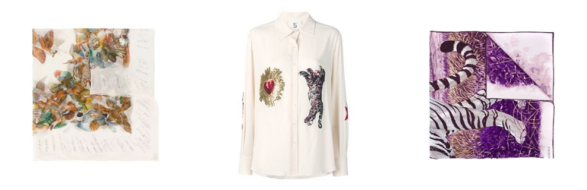

In [99]:
n = 0 #random.randint(0, len(personas) - 1)
print(personas[n])

indices = reversed(sorted_indices[:,n])

print(n)
num_images = 3
cols = 10  # images per row
rows = int(np.ceil(num_images / cols))

plt.figure(figsize=(cols * 2, rows * 2))  # adjust size as needed

for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(images[indices[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [105]:
print("Kelsey, a 47-year-old Southern woman, finds balance between her structured career \nand creative hobbies, her love for animals and community reflected in her volunteer work.")

Kelsey, a 47-year-old Southern woman, finds balance between her structured career 
and creative hobbies, her love for animals and community reflected in her volunteer work.


In [100]:
with open(f'../data_preparation/{image_set}/image_embeddings_fashionclip.pkl', 'rb') as f:
    image_embeddings = pickle.load(f)
text_inputs = processor(text=personas[n], return_tensors="pt", padding=True, truncation=True, max_length=77)
with torch.no_grad():
    persona_embedding = model.get_text_features(**text_inputs)
clip_dot_products_list = image_embeddings @ persona_embedding.T
clip_dot_products_list = clip_dot_products_list.cpu().numpy()
clip_sorted_indices = np.argsort(clip_dot_products_list, axis=0).squeeze()[::-1]

Kelsey, a 47-year-old Southern woman, finds balance between her structured career and creative hobbies, her love for animals and community reflected in her volunteer work.
0


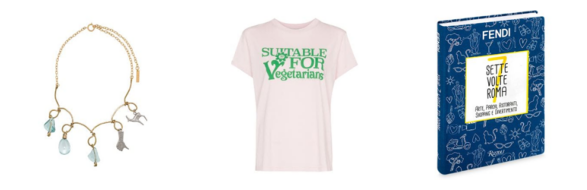

In [101]:
print(personas[n])
print(n)
num_images = 3
cols = 10  # images per row
rows = int(np.ceil(num_images / cols))

plt.figure(figsize=(cols * 2, rows * 2))  # adjust size as needed

for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(images[clip_sorted_indices[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

[1.6894152] [0.05348784]


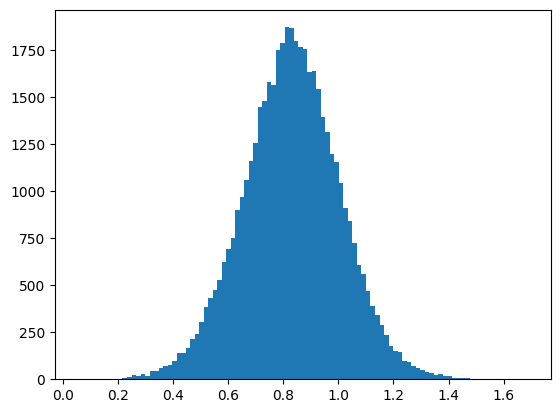

In [102]:
import matplotlib.pyplot as plt
import random

scores = clip_dot_products_list

_ = plt.hist(scores, bins=100)
print(max(scores), min(scores))